# Diffraction pattern analysis

Cleaned-up, English versions of the two Python scripts originally used to analyze the double-slit patterns in this project (see [`report/main.pdf`](report/main.pdf) for the full writeup). One method per exposure regime:

1. **High intensity** (non-attenuated) pattern: deliberately overexposed to make the fringes easy to see, which saturates the film near the center. Fit the *positions* of hand-identified minima against fringe order.
2. **Single photon** (attenuated) pattern: exposed slowly enough to stay in the film's linear response range. Fit the whole intensity profile directly.

The reusable code is in [`modules/diffraction_fit.py`](modules/diffraction_fit.py); this notebook just calls it.

In [1]:
import sys
sys.path.insert(0, "modules")

import numpy as np
import diffraction_fit as df

## 1. High-intensity pattern: minima positions

Kentmere Pan 400 film, developed at ISO 400, exposed for about 40 s with only $F_1 = F_2 \lesssim 0.8\%$ engaged, $D = (4021 \pm 5)$ mm.

The diffraction (envelope) and interference minima positions below were originally measured by eye on this same scan at a higher resolution (8000 px wide); they're rescaled here by the resolution ratio to match the 3000-px-wide copy of the image shipped in `acquisitions/`. If you're running this on your own photo, replace these with pixel x-coordinates read off *your* image instead.

In [2]:
# Minima positions and center, originally measured by eye on the same scan
# at 8000 px width; rescaled to the 3000-px-wide copy shipped here.
_ORIGINAL_WIDTH_PX = 8000
_NEW_WIDTH_PX = 3000
_RESCALE = _NEW_WIDTH_PX / _ORIGINAL_WIDTH_PX

_center_x_orig = 4057
_center_y_orig = 956
_diffraction_minima_orig = np.array([-1911, -948, 950, 1895])          # offsets from center
_interference_minima_orig = np.array([                                  # offsets from center
    -1911, -1794, -1677, -1533, -1386, -1239, -1093, -948, -804, -657, -509,
    -365, -220, -74, 72, 218, 363, 508, 654, 801, 950, 1091, 1238,
    1387, 1535, 1680, 1790, 1909,
])
_sigma_diffraction_orig = 60.0
_sigma_interference_orig = 32.0

center_x_px = _center_x_orig * _RESCALE
center_y_px = round(_center_y_orig * _RESCALE)
diffraction_minima_px = center_x_px + _diffraction_minima_orig * _RESCALE
interference_minima_px = center_x_px + _interference_minima_orig * _RESCALE
sigma_diffraction_px = _sigma_diffraction_orig * _RESCALE
sigma_interference_px = _sigma_interference_orig * _RESCALE

pixel_size_mm = 140 / _NEW_WIDTH_PX   # 140 mm reference width, see README
wavelength_nm, sigma_wavelength_nm = 520.0, 15.0
distance_mm, sigma_distance_mm = 4021.0, 5.0

Diffraction minima: slope = 356.62 +/- 7.12 px (reduced chi^2 = 0.013, ndof = 2)
  a = (0.126 +/- 0.004) mm
Interference minima: slope = 51.42 +/- 0.27 px (reduced chi^2 = 1.102, ndof = 26)
  b = (0.871 +/- 0.026) mm


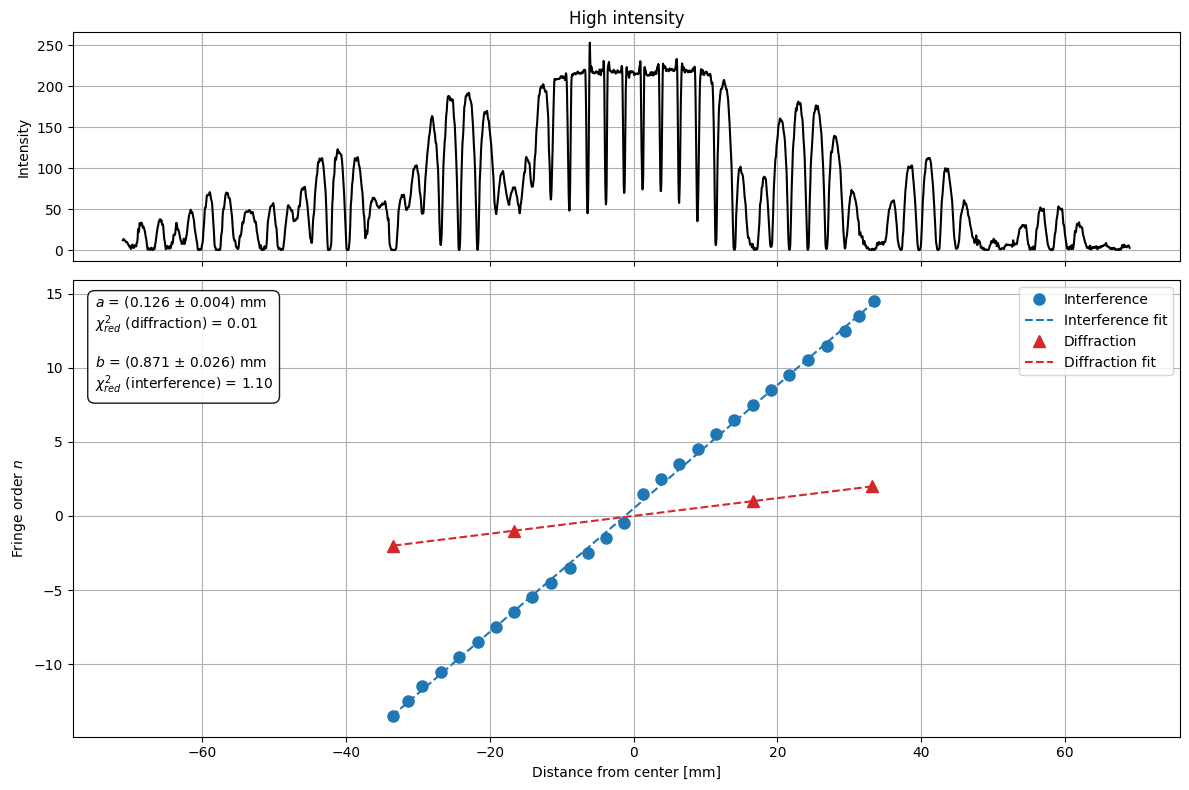

In [3]:
gray = df.load_grayscale("acquisitions/double-slit/pattern.jpg")
profile, profile_std = df.extract_intensity_profile(gray, center_y_px, band_height_px=15)

diffraction_fit = df.fit_minima_positions(
    diffraction_minima_px, center_x_px, sigma_diffraction_px, half_integer_order=False,
    pixel_size_mm=pixel_size_mm,
    wavelength_nm=wavelength_nm, sigma_wavelength_nm=sigma_wavelength_nm,
    distance_mm=distance_mm, sigma_distance_mm=sigma_distance_mm,
)
interference_fit = df.fit_minima_positions(
    interference_minima_px, center_x_px, sigma_interference_px, half_integer_order=True,
    pixel_size_mm=pixel_size_mm,
    wavelength_nm=wavelength_nm, sigma_wavelength_nm=sigma_wavelength_nm,
    distance_mm=distance_mm, sigma_distance_mm=sigma_distance_mm,
)
print(df.summarize_minima_fit(diffraction_fit, interference_fit))

x_mm = (np.arange(len(profile)) - center_x_px) * pixel_size_mm
df.plot_minima_fit(x_mm, profile, diffraction_fit, interference_fit, pixel_size_mm, title="High intensity");

Published result (same method, same image): $a = (0.13 \pm 0.04)$ mm, $b = (0.8 \pm 0.2)$ mm.

## 2. Single-photon pattern: intensity fit

Ilford Delta 3200 Professional film, push-processed to ISO 6400, exposed for about 8 hours with all five filters engaged ($F_1 = F_2 = F_3 = F_4 \lesssim 0.8\%$, $F_5 \lesssim 8\%$), $D = (4091 \pm 5)$ mm.

Center and band height below were read off this image directly (no minima-picking needed here, since the exposure is unsaturated).

In [4]:
center_x_px = 1493.5
center_y_px = 376
band_height_px = 40
pixel_size_mm = 0.023350   # see README for how this was calibrated

wavelength_nm, sigma_wavelength_nm = 520.0, 15.0
distance_mm, sigma_distance_mm = 4091.0, 5.0

# Starting guess for the fit, from the slit width/spacing we roughly expect:
a0_mm, b0_mm = 0.1, 0.8
p0 = [wavelength_nm * 1e-6 * distance_mm / a0_mm, wavelength_nm * 1e-6 * distance_mm / b0_mm, 1.0]

alpha = (13.977 +/- 0.154) mm, beta = (2.481 +/- 0.005) mm, C = 0.968 +/- 0.011
reduced chi^2 = 0.809 (ndof = 472)
a = (0.152 +/- 0.005) mm
b = (0.857 +/- 0.025) mm


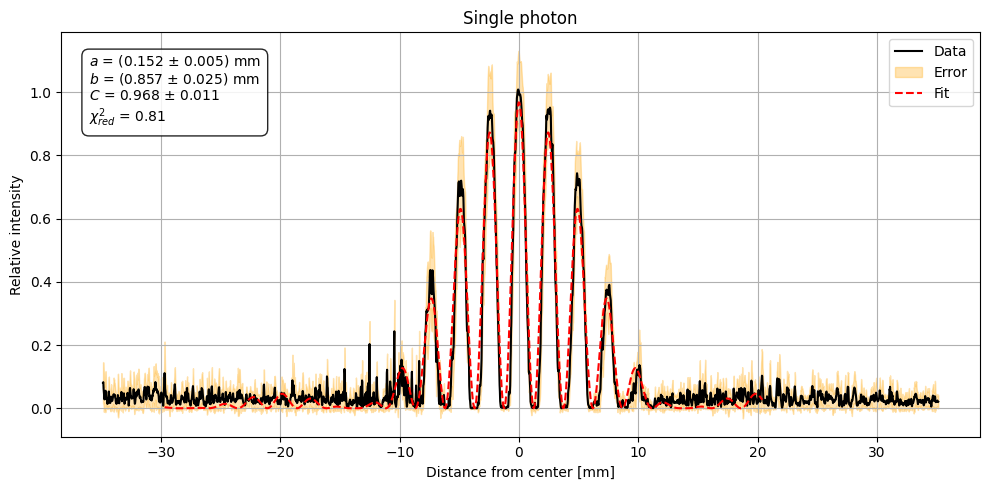

In [5]:
gray = df.load_grayscale("acquisitions/double-slit-single-photon/pattern.jpg")
profile, profile_std = df.extract_intensity_profile(gray, center_y_px, band_height_px)

x_mm = (np.arange(len(profile)) - center_x_px) * pixel_size_mm
peak = float(np.interp(center_x_px, np.arange(len(profile)), profile))
intensity = profile / peak
intensity_err = profile_std / peak

fit = df.fit_intensity_profile(
    x_mm, intensity, intensity_err, p0,
    wavelength_nm, sigma_wavelength_nm, distance_mm, sigma_distance_mm,
)
print(df.summarize_intensity_fit(fit))

df.plot_intensity_fit(x_mm, intensity, intensity_err, fit, title="Single photon");

Published result (same method, same image): $a = (0.15 \pm 0.01)$ mm, $b = (0.85 \pm 0.03)$ mm.